In [13]:
import matplotlib.pyplot as plt
import numpy as np

Primero miremos que la entropía depende de la distribución de probabilidad. Cuando los eventos tienen probabilidades similares entre si, la entropía es mayor. Si la probabilidad alta se concentra en menos eventos, la entropía es menor.

Text(0.5, 1.0, 'Entropía: 0.721763067193911')

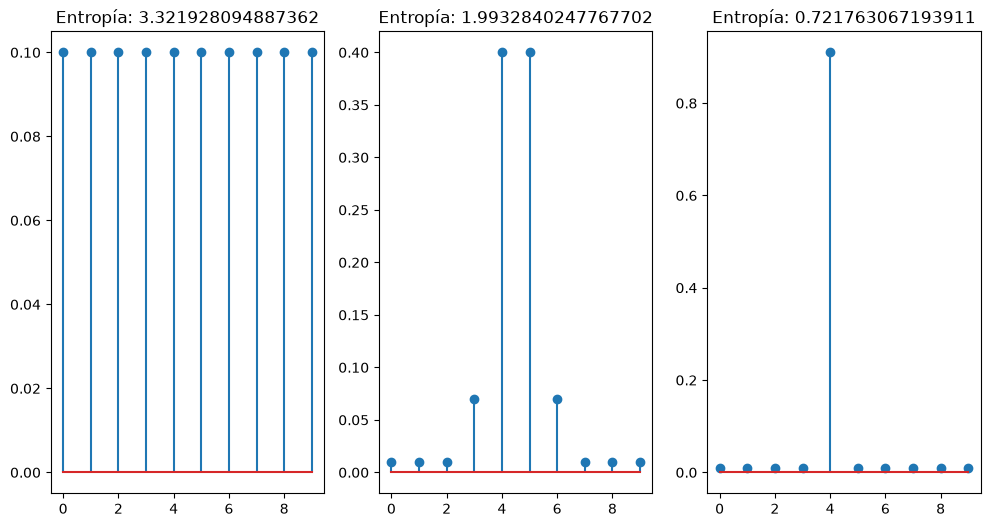

In [14]:
def H(x):
  x=np.array(x) #Garantizando que el arreglo es numérico
  x=np.where(x==0,1e-20,x) #Garantizando que no hay ceros en el vector
  x=x/np.sum(x) #Garantizando que el vector está normalizado y corresponde a probabilidades
  return -np.sum(x*np.log2(x))

plt.figure(figsize=(12,6))
plt.subplot(1,3,1)
pr=[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
plt.stem(pr)
plt.title('Entropía: '+str(H(pr)))

plt.subplot(1,3,2)
pr=[0.01, 0.01, 0.01, 0.07, 0.4, 0.4, 0.07, 0.01, 0.01, 0.01]
plt.stem(pr)
plt.title('Entropía: '+str(H(pr)))

plt.subplot(1,3,3)
pr=[0.01, 0.01, 0.01, 0.01, 0.91, 0.01, 0.01, 0.01, 0.01, 0.01]
plt.stem(pr)
plt.title('Entropía: '+str(H(pr)))


## Entropía de una fuente con símbolos equiprobables

Supongamos una fuente que puede producir (L) símbolos distintos

$$
x_1,x_2,\ldots,x_L
$$

y que todos son **equiprobables**:

$$
P(x_i)=\frac{1}{L}.
$$

La entropía de esta fuente es

$$
H(X)= -\sum_{i=1}^{L}P(x_i)\log_2P(x_i) =  -\sum_{i=1}^{L}\frac{1}{L}\log_2\frac{1}{L} = \log_2 L
$$

Por ejemplo, si existen 8 símbolos,

$$
H(X)=\log_2 8=3\text{ bits/símbolo}.
$$

Esto tiene una interpretación inmediata: cada símbolo puede representarse mediante exactamente 3 bits:

```text
000
001
010
011
100
101
110
111
```

De manera similar, si existen 16 símbolos,

$$
H(X)=\log_2 16=4\text{ bits/símbolo}.
$$

El problema conceptual aparece cuando (L) **no es una potencia de 2**.

### El caso de 14 símbolos

Supongamos ahora que tenemos 14 símbolos equiprobables. La entropía es

$$
H(X)=\log_2 14\approx 3.8074\text{ bits/símbolo}.
$$

¿Cómo puede utilizarse un promedio de (3.8074) bits si físicamente no podemos transmitir una fracción de bit?

Si codificamos **cada símbolo por separado** mediante una palabra binaria de longitud fija, necesitamos

$$
\left\lceil\log_2 14\right\rceil=4\text{ bits}.
$$

Con 3 bits solamente existen

$$
2^3=8
$$

palabras binarias diferentes, que no son suficientes. Con 4 bits existen

$$
2^4=16,
$$

por lo que podemos asignar 14 de ellas a nuestros símbolos y dejar 2 sin utilizar.

Por tanto, si codificamos los símbolos **individualmente**, efectivamente gastamos 4 bits por símbolo.

La entropía de (3.8074) bits no afirma que podamos enviar físicamente cada símbolo utilizando exactamente (3.8074) bits. Afirma que, considerando secuencias suficientemente largas, podemos hacer que el **número promedio de bits por símbolo original** se aproxime tanto como queramos a (3.8074).

## Agrupar varios símbolos

La clave está en dejar de codificar cada símbolo (x_i) independientemente.

Supongamos que agrupamos los símbolos originales en bloques de (k) símbolos:

$$
Y=(X_1,X_2,\ldots,X_k).
$$

Cada bloque completo se considera ahora un nuevo símbolo (Y_j).

Como cada posición puede contener cualquiera de los (L) símbolos originales, existen

$$
L^k
$$

bloques posibles.

Si los símbolos originales son independientes y equiprobables, estos (L^k) bloques también son equiprobables.

Para identificar uno de ellos mediante una codificación binaria de longitud fija necesitamos

$$
B_k=\left\lceil\log_2(L^k)\right\rceil
$$

bits.

Utilizando la propiedad del logaritmo,

$$
\log_2(L^k)=k\log_2 L,
$$

por lo que

$$
B_k=\left\lceil k\log_2L\right\rceil.
$$

Pero estos bits representan **(k) símbolos originales**. Por tanto, el número de bits utilizados por símbolo original es

$$
R_k=
\frac{\left\lceil k\log_2L\right\rceil}{k}.
$$

Aquí aparece el resultado importante.

Como

$$
z\leq \lceil z\rceil < z+1,
$$

podemos escribir

$$
k\log_2L
\leq
\left\lceil k\log_2L\right\rceil
<
k\log_2L+1.
$$

Dividiendo todo entre (k),

$$
\log_2L
\leq
R_k
<
\log_2L+\frac{1}{k}.
$$

Por tanto,

$$
\boxed{
\lim_{k\rightarrow\infty}R_k=\log_2L
}
$$

que es precisamente la entropía de la fuente.

## Ejemplo con 14 símbolos

Para (L=14),

$$
H(X)=\log_2 14\approx3.8074.
$$

Si codificamos individualmente:

$$
k=1:
\qquad
R_1=\frac{\lceil3.8074\rceil}{1}=4.
$$

Si agrupamos dos símbolos:

$$
14^2=196
$$

bloques posibles y

$$
R_2
=\frac{\lceil\log_2 196\rceil}{2}=\frac{8}{2}=4
$$

Todavía no hemos ganado nada.

Con tres símbolos:

$$
R_3
=\frac{\lceil3\log_2 14\rceil}{3}=\frac{12}{3}=4
$$

Pero con cuatro símbolos:

$$
R_4=\frac{\lceil4\log_2 14\rceil}{4}=\frac{16}{4}=4
$$

Con cinco:

$$
R_5
=\frac{\lceil5\log_2 14\rceil}{5}=\frac{20}{5}=4
$$

Y con seis aparece finalmente una reducción:

$$
R_6
=\frac{\lceil6\log_2 14\rceil}{6}=\frac{23}{6}=\approx3.8333.
$$

Ya estamos muy cerca de

$$
3.8074.
$$

Al aumentar (k), el cociente continúa acercándose a este valor.

## ¿De dónde proviene la ganancia?

Cuando codificamos un solo símbolo tenemos 14 posibilidades, pero debemos utilizar palabras de 4 bits. Los 4 bits permiten representar 16 posibilidades:

$$
2^4=16.
$$

Por tanto, estamos desperdiciando parte de la capacidad disponible.

El agrupamiento permite aprovechar progresivamente mejor el espacio de palabras binarias.

Por ejemplo, para (k=6) existen

$$
14^6=7,529,536
$$

bloques posibles.

Con 22 bits solamente podemos representar

$$
2^{22}=4,194,304
$$

posibilidades, lo cual no alcanza. Pero con 23 bits podemos representar

$$
2^{23}=8,388,608.
$$

Por tanto, 23 bits son suficientes para transmitir un bloque de 6 símbolos.

El costo por símbolo original es entonces

$$
\frac{23}{6}\approx3.8333\text{ bits/símbolo},
$$

en lugar de 4.

A medida que el bloque se hace mayor, el desperdicio producido por tener que redondear al siguiente número entero de bits se reparte entre más símbolos.

## Interpretación de la gráfica

El código

```python
for k in range(1,200):
    ki.append(k)
    hi.append(np.ceil(k*np.log2(L))/k)
```

está calculando precisamente

$$
R_k=
\frac{\left\lceil k\log_2L\right\rceil}{k}.
$$

La línea horizontal

```python
plt.hlines(
    xmin=1,
    xmax=max(ki),
    y=np.log2(L),
    color='r',
    linestyle='--'
)
```

representa

$$
H(X)=\log_2L.
$$

La curva no tiene por qué descender monótonamente: presenta pequeños saltos debido a la función techo (\lceil\cdot\rceil). Sin embargo, queda atrapada en el intervalo

$$
\log_2L
\leq R_k
<
\log_2L+\frac{1}{k},
$$

y como $1/k\rightarrow0$, necesariamente converge hacia la entropía.

### Idea fundamental

La afirmación

$$
H(X)=\log_2 14\approx3.8074\text{ bits/símbolo}
$$

**no significa que cada símbolo pueda codificarse individualmente usando una fracción de bit**.

Significa que, al codificar secuencias suficientemente largas de símbolos, podemos conseguir que

$$
\boxed{
\frac{\text{bits transmitidos}}
{\text{símbolos originales transmitidos}}
\rightarrow H(X)
}
$$

En otras palabras, **la entropía no debe interpretarse necesariamente como la longitud de la palabra binaria asignada a un símbolo individual, sino como el límite fundamental del número promedio de bits por símbolo cuando se codifican secuencias largas**.

Este ejemplo constituye una forma particularmente sencilla de visualizar la idea central del **teorema de codificación de fuente de Shannon**: para una fuente sin memoria, la tasa de codificación puede aproximarse arbitrariamente a su entropía cuando se codifican bloques suficientemente largos.


Bits necesarios para transmitir 11 símbolos equiprobables: 4.0 bits
Pero la entropía de esta fuente es: 3.4594316186372973 bits
Si se transmiten en grupos de 11 símbolos originales, ahora hay 45949729863572161 símbolos equiprobables, y se necesitan 56.0 bits para transmitirlos
Pero como en cada símbolo nuevo, hay 16 símbolos originales, la entropía por símbolo original es: 3.5 bits


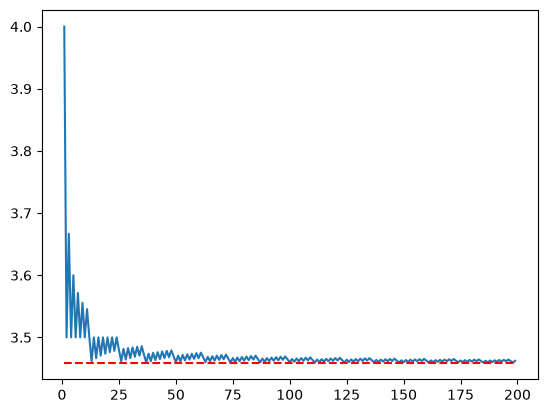

In [7]:
#Si tuviéramos que transmitir L símbolos equiprobables, con codificación binaria normal, necesitaríamos
L=11
print(f'Bits necesarios para transmitir {L} símbolos equiprobables: {np.ceil(np.log2(L))} bits')
print(f'Pero la entropía de esta fuente es: {np.log2(L)} bits')

#Dónde está la diferencia? Si yo agrupo los símbolos y los transmito de a k símbolos juntos, aparecen ahora
k=16
print(f'Si se transmiten en grupos de {L} símbolos originales, ahora hay {L**k} símbolos equiprobables, y se necesitan {np.ceil(k*np.log2(L))} bits para transmitirlos')
print(f'Pero como en cada símbolo nuevo, hay {k} símbolos originales, la entropía por símbolo original es: {np.ceil(k*np.log2(L))/k} bits')
ki=[]
hi=[]

for k in range(1,200):
    ki.append(k)
    hi.append(np.ceil(k*np.log2(L))/k)
plt.plot(ki,hi)
plt.hlines(xmin=1, xmax=max(ki), y=np.log2(L), color='r', linestyle='--')

## Entropía de texto

Ahora miremos la entropía de palabras y letras. Para ello necesitamos primero tomar un texto cualquiera como referencia

In [2]:
with open('./libros/libro_muertos.txt', encoding='latin1') as file:
  lines = file.readlines()

In [9]:
#Un ejemplo bien interesante. La entropía de palabras y de letras de un documento
cad=''
caracteres='abcdefghijklmnñopqrstuvwxyzáéíóú'
for li in lines:
  cad=cad+' '+li.lower()
contador={}
for ch in cad:
  if(ch in caracteres):
    if(ch not in contador.keys()):
      contador[ch]=1
    else:
      contador[ch]+=1
print(contador)
n=list(contador.values())
pr=np.array(n)/np.sum(n)
print('Número de letras = ',len(pr))
print('Entropía de las letras = ',H(pr))

#Si todas las letras fueran equiprobables,
n=np.ones(len(pr))
pr=np.array(n)/np.sum(n)
print('Entropía de las letras (si fueran equiprobables) = ',H(pr))

#entropia de las vocales
n=[contador['a'], contador['e'], contador['i'], contador['o'], contador['u']]
pr=np.array(n)/np.sum(n)

print('Entropía de las vocales: ',-np.sum(pr*np.log2(pr)))

{'e': 5279, 'l': 2302, 'i': 2180, 'b': 301, 'r': 2264, 'o': 3139, 'd': 1725, 's': 2954, 'm': 1244, 'u': 1458, 't': 1713, 'a': 3701, 'n': 2650, 'w': 5, 'c': 1661, 'q': 279, 'z': 85, 'p': 833, 'g': 331, 'í': 237, 'h': 248, 'y': 297, 'ó': 240, 'v': 427, 'á': 147, 'k': 12, 'f': 282, 'j': 93, 'ú': 38, 'x': 61, 'é': 67, 'ñ': 43}
Número de letras =  32
Entropía de las letras =  4.098814720971937
Entropía de las letras (si fueran equiprobables) =  5.0
Entropía de las vocales:  2.195687534779612


In [10]:
#Calcular la entropía de las palabras
cadena = ''

for linea in lines:
    cadena = cadena +' '+ linea.lower()
#Para quitar los caracteres no alfanuméricos
permited='0123456789áéíóúñabcdefghijklmnopqrstuvwxyz '
cadena = ''.join([e for e in cadena.lower() if e in permited])

palabras = cadena.split()
contador_palabras = {}
for palabra in palabras:
  if (palabra not in contador_palabras.keys()):
    contador_palabras[palabra] = 1
  else:
    contador_palabras[palabra] += 1
print(contador_palabras)
n_p = list(contador_palabras.values())
pr=np.array(n_p)/np.sum(n_p)
print("Entropía de las palabras =",H(pr))
print('Num palabras: ',len(contador_palabras))
print("Entropía de las palabras (si fueran equiprobables) = ",np.log2(len(contador_palabras)))


{'el': 321, 'libro': 11, 'de': 396, 'los': 163, 'muertos': 7, 'samael': 4, 'aun': 4, 'weor': 4, 'instituto': 2, 'cultural': 2, 'quetzalcoatl': 2, 'antropología': 2, 'psicoanalítica': 2, 'ac': 2, 'httpsamaelgnosisnet': 2, 'y': 200, 'httpsamaelgnosisorg': 2, 'índice': 1, 'prologo': 2, 'del': 104, 'editor': 2, 'introducción': 2, 'capítulo': 8, 'i': 2, 'la': 407, 'muerte': 58, 'rayo': 7, 'lo': 35, 'que': 182, 'continua': 2, 'cuerpo': 82, 'vital': 27, 'quinta': 9, 'dimensión': 17, 'ii': 2, 'ángeles': 19, 'iii': 2, 'tribunales': 4, 'karma': 7, 'iv': 2, 'cuatro': 6, 'círculos': 4, 'avitchi': 13, 'reino': 8, 'mineral': 10, 'región': 17, 'celular': 14, 'molecular': 31, 'mundo': 54, 'electrónico': 22, 'mucho': 6, 'se': 92, 'ha': 9, 'hablado': 1, 'mayoría': 1, 'las': 68, 'gentes': 8, 'creen': 5, 'aseguran': 3, 'nadie': 6, 'sabe': 1, 'nada': 3, 'al': 40, 'respecto': 1, 'pero': 17, 'nosotros': 9, 'gnósticos': 1, 'afirmamos': 1, 'con': 70, 'conocimiento': 5, 'objetivo': 3, 'es': 141, 'paso': 1, 'un'

## Probabilidad condicional

Hasta ahora hemos considerado la probabilidad de que ocurra un evento sin disponer de información adicional. Sin embargo, en muchos problemas conocemos cierta información que modifica las probabilidades de los posibles resultados.

Supongamos que tenemos un conjunto de palabras y escogemos una palabra al azar. Podemos definir una variable aleatoria (X) que representa **la palabra seleccionada**.

Si una determinada palabra (x_i) aparece con probabilidad (P(X=x_i)), podemos calcular la entropía de la variable (X):

$$
H(X)=-\sum_i P(X=x_i)\log_2P(X=x_i)
$$

Esta entropía representa nuestra incertidumbre acerca de cuál es la palabra seleccionada **antes de recibir información adicional**.

Ahora supongamos que, antes de intentar identificar la palabra, conocemos su **primera letra**.

Esta información cambia el problema.

Si sabemos, por ejemplo, que la primera letra es `c`, inmediatamente podemos descartar todas las palabras que no comiencen por `c`.

Para formalizar esta idea necesitamos introducir el concepto de **probabilidad condicional**.

---

## Probabilidad de una palabra conociendo su primera letra

Definamos una segunda variable aleatoria (Y), que representa la primera letra de la palabra.

Por ejemplo, si

```text
X = "casa"
```

entonces

```text
Y = "c"
```

Antes de conocer la primera letra podemos preguntarnos por la probabilidad de una palabra:

$$
P(X=x_i)
$$

Pero si conocemos que la primera letra es (y_j), la pregunta cambia:

> ¿Cuál es la probabilidad de que la palabra sea (x_i), sabiendo que su primera letra es (y_j)?

Esta probabilidad se escribe:

$$
P(X=x_i\mid Y=y_j)
$$

y se denomina **probabilidad condicional**.

En general, para dos eventos (A) y (B):

$$
P(A\mid B)=\frac{P(A\cap B)}{P(B)}
$$

siempre que

$$
P(B)>0.
$$

La expresión (P(A\mid B)) se lee:

> Probabilidad de (A) dado el evento (B).

La idea fundamental es que **ya no estamos considerando todo el espacio de posibilidades**. Al conocer (B), restringimos nuestra atención únicamente a los casos compatibles con (B).

---

## Ejemplo con palabras

Supongamos que tenemos las siguientes palabras:

```text
casa
carro
cama
perro
pato
gato
```

Si todas aparecen una sola vez, antes de conocer ninguna información existen 6 posibilidades equiprobables:

$$
P(X=x_i)=\frac{1}{6}
$$

Pero supongamos ahora que sabemos que la palabra comienza por `c`.

Entonces solamente quedan:

```text
casa
carro
cama
```

Nuestro espacio de posibilidades se ha reducido.

Condicionado a que la primera letra sea `c`, tenemos:

$$
P(X=\text{casa}\mid Y=\text{c})=\frac{1}{3}
$$

$$
P(X=\text{carro}\mid Y=\text{c})=\frac{1}{3}
$$

$$
P(X=\text{cama}\mid Y=\text{c})=\frac{1}{3}
$$

mientras que, por ejemplo,

$$
P(X=\text{perro}\mid Y=\text{c})=0.
$$

Por tanto, conocer la primera letra **modifica la distribución de probabilidad de (X)**.

Y si cambia la distribución de probabilidad, también cambia su entropía.

---

## Entropía después de conocer una letra

Supongamos que conocemos que la primera letra es específicamente `c`.

Podemos calcular la entropía únicamente de las palabras que comienzan por esa letra:

$$
H(X\mid Y=\text{c})=-\sum_i
P(x_i\mid Y=\text{c})\log_2P(x_i\mid Y=\text{c})
$$

En nuestro ejemplo existen tres palabras equiprobables que comienzan por `c`, por lo que:

$$
H(X\mid Y=\text{c})=\log_2 3=\approx 1.585
$$

bits.

Pero si conocemos que la palabra comienza por `g`, solamente existe una posibilidad:

```text
gato
```

Por tanto:

$$
H(X\mid Y=\text{g})=0.
$$

No existe incertidumbre: conocer la primera letra permitió identificar completamente la palabra.

Esto muestra algo importante: **cada letra puede reducir la incertidumbre en una cantidad diferente**.

Una letra muy frecuente puede dejarnos muchas palabras posibles, mientras que una letra poco frecuente puede reducir considerablemente el conjunto de candidatos.

---

## Entropía condicional

El problema es que antes de observar la primera letra no sabemos cuál de ellas vamos a recibir.

Podríamos recibir `c`, `p`, `g`, etc.

Por tanto, necesitamos calcular la incertidumbre que esperamos tener **en promedio después de conocer la primera letra**.

Esta cantidad se denomina **entropía condicional**:

$$
H(X\mid Y)
$$

y se calcula como:

$$
H(X\mid Y)=\sum_j P(Y=y_j)H(X\mid Y=y_j)
$$

Es decir:

1. consideramos cada posible primera letra;
2. calculamos la entropía de las palabras que comienzan por esa letra;
3. ponderamos esa entropía por la probabilidad de observar dicha letra.

En el código, esto corresponde precisamente a:

```python
H = 0

for letra in inicio:
    palabras2 = [pal for pal in palabras if pal[0] == letra]

    hc = entropia_de_palabras(palabras2)

    pr = len(palabras2) / len(palabras)

    H = H + pr * hc
```

La variable

```python
hc
```

representa:

$$
H(X\mid Y=y_j)
$$

es decir, la entropía de las palabras cuando sabemos que comienzan por una determinada letra.

Mientras que:

```python
pr = len(palabras2) / len(palabras)
```

estima:

$$
P(Y=y_j)
$$

la probabilidad de que una palabra comience por esa letra.

Finalmente:

```python
H = H + pr * hc
```

implementa:

$$
H(X\mid Y)=\sum_jP(Y=y_j)H(X\mid Y=y_j)
$$

---

## ¿Cuánta información nos dio conocer la primera letra?

Ahora podemos comparar dos situaciones.

**Antes de conocer la primera letra**, nuestra incertidumbre acerca de la palabra es:

$$
H(X)
$$

**Después de conocer la primera letra**, nuestra incertidumbre promedio es:

$$
H(X\mid Y)
$$

Por tanto, la reducción de incertidumbre producida por conocer (Y) es:

$$
H(X)-H(X\mid Y)
$$

Esta diferencia es la **información mutua** entre (X) y (Y):

$$
I(X;Y)=H(X)-H(X\mid Y)
$$

En este ejemplo puede interpretarse directamente como:

> **¿Cuántos bits de incertidumbre acerca de la palabra eliminamos, en promedio, al conocer su primera letra?**

Si inicialmente tenemos, por ejemplo,

$$
H(X)=12.4\text{ bits}
$$

y después de conocer la primera letra obtenemos:

$$
H(X\mid Y)=8.7\text{ bits},
$$

entonces:

$$
I(X;Y)=12.4-8.7=3.7\text{ bits}.
$$

Esto significa que **conocer la primera letra nos proporciona, en promedio, 3.7 bits de información acerca de cuál es la palabra**.

---

## La información como reducción de incertidumbre

Este resultado permite introducir una interpretación fundamental de la teoría de la información.

La información no tiene que entenderse como una propiedad aislada de un dato. Puede entenderse como **la reducción de incertidumbre que produce conocer ese dato**.

Antes de conocer (Y):

$$
\text{incertidumbre}=H(X)
$$

Después de conocer (Y):

$$
\text{incertidumbre}=H(X\mid Y)
$$

Por tanto:

$$
\boxed{
\text{información obtenida}
=\text{incertidumbre inicial}-\text{incertidumbre restante}
}
$$

o formalmente:

$$
\boxed{
I(X;Y)=H(X)-H(X\mid Y)
}
$$

En nuestro ejemplo, (X) representa la palabra y (Y) representa su primera letra. Como la primera letra está relacionada con la palabra, conocerla reduce el número de posibilidades y, por tanto, reduce nuestra incertidumbre.

Esta idea será especialmente importante posteriormente en aprendizaje automático. Por ejemplo, en un **árbol de decisión**, una característica resulta útil precisamente cuando conocer su valor reduce significativamente la incertidumbre acerca de la variable que queremos predecir. Esa reducción de entropía es lo que se denomina habitualmente **ganancia de información**.


In [17]:
#Primeras letras
letra_inicial=[pal[0] for pal in palabras]
letra_inicial=list(set(letra_inicial))

def entropia_de_palabras(palabras2):
  contador_palabras = {}
  for palabra in palabras2:
    if (palabra not in contador_palabras.keys()):
        contador_palabras[palabra] = 1
    else:
        contador_palabras[palabra] += 1
  n=list(contador_palabras.values())
  pr=np.array(n)/np.sum(n)
  return -np.sum(pr*np.log2(pr))

Hc=0 #Entropia condicional
for letra in letra_inicial:
  palabras2=[pal for pal in palabras if pal[0]==letra]
  hc=entropia_de_palabras(palabras2)
  pr=len(palabras2)/len(palabras)
  print('Letra:',letra,', Probabilidad de la letra:', pr, ', Entropía de la palabras que comienzan con esa letra:', hc)
  Hc=Hc+pr*hc
print('')
print('='*80)
print('La entropía de las palabras es: ',entropia_de_palabras(palabras))
print('La entroía condicional es: ',Hc)
print('La información mutua entre letras y palabras es: ',entropia_de_palabras(palabras)-Hc)


Letra: 4 , Probabilidad de la letra: 0.0006700616456714018 , Entropía de la palabras que comienzan con esa letra: 0.9709505944546686
Letra: c , Probabilidad de la letra: 0.08188153310104529 , Entropía de la palabras que comienzan con esa letra: 6.218505693556039
Letra: p , Probabilidad de la letra: 0.05789332618600911 , Entropía de la palabras que comienzan con esa letra: 6.310926046753058
Letra: é , Probabilidad de la letra: 0.002278209595282766 , Entropía de la palabras que comienzan con esa letra: 1.5739889616503064
Letra: x , Probabilidad de la letra: 0.0002680246582685607 , Entropía de la palabras que comienzan con esa letra: 1.0
Letra: s , Probabilidad de la letra: 0.07035647279549719 , Entropía de la palabras que comienzan con esa letra: 5.432038447352332
Letra: 2 , Probabilidad de la letra: 0.00040203698740284106 , Entropía de la palabras que comienzan con esa letra: 1.584962500721156
Letra: m , Probabilidad de la letra: 0.057759313856874835 , Entropía de la palabras que comien

In [19]:
import pandas as pd
data=pd.read_csv('./data/permanencia_ingenierias.csv', sep=';', encoding='latin1', decimal=',')
data.head()

,Edad,SEXO,ALERTASROJAS,ALERTASNARANJAS,ALERTASACADEMICAS,ALERTASMANUALES,CAL.PSICOSOCIAL,CAL.FAMILIAR,CAL.SOCIECONOMICO,CAL.ACADEMICO,CRÉDITOS REPROBADOS,CRÉDITOS APROBADOS,CRÉDITOS CANCELADOS,CREDITOS INTENTADOS,PROMEDIO GLOBAL,ULTIMO ESTADO ACADÉMICO,APOYOS ECONÓMICO EN MATRICULA,APOYO INSTITUCIONAL,DESERSIÓN
0,21,M,14,17,0,0,10.31,28.21,22.37,10.61,3,65,0,68,3.832059,Estado académico normal,SI,SI,NO
1,21,F,14,15,0,0,5.15,28.21,22.37,15.15,15,84,9,108,3.614646,Estado académico normal,SI,SI,NO
2,19,F,13,19,0,0,8.25,28.21,21.05,15.15,6,8,3,17,2.855000,Advertencia académica,SI,SI,SI
3,20,F,12,18,0,0,9.28,35.90,15.79,10.61,3,44,3,50,3.808936,Estado académico normal,SI,NO,NO
4,20,F,12,14,0,0,10.31,17.95,23.68,4.55,0,149,4,153,4.202685,Estado académico normal,SI,SI,NO


In [20]:
pr=data['DESERSIÓN'].value_counts().values
print(pr)
def H(x):
  x=np.array(x) #Garantizando que el arreglo es numérico
  x=x/np.sum(x) #Garantizando que el vector está normalizado y corresponde a probabilidades
  return -np.sum(x*np.log2(x))

Entropia_Desersion=H(pr)
print('Entropia de la desersión es: ',Entropia_Desersion)

[800 114]
Entropia de la desersión es:  0.5427960734010016


In [26]:
data_org=pd.read_csv('./data/permanencia_ingenierias.csv', sep=';', encoding='latin1', decimal=',')
data_org.head()

,Edad,SEXO,ALERTASROJAS,ALERTASNARANJAS,ALERTASACADEMICAS,ALERTASMANUALES,CAL.PSICOSOCIAL,CAL.FAMILIAR,CAL.SOCIECONOMICO,CAL.ACADEMICO,CRÉDITOS REPROBADOS,CRÉDITOS APROBADOS,CRÉDITOS CANCELADOS,CREDITOS INTENTADOS,PROMEDIO GLOBAL,ULTIMO ESTADO ACADÉMICO,APOYOS ECONÓMICO EN MATRICULA,APOYO INSTITUCIONAL,DESERSIÓN
0,21,M,14,17,0,0,10.31,28.21,22.37,10.61,3,65,0,68,3.832059,Estado académico normal,SI,SI,NO
1,21,F,14,15,0,0,5.15,28.21,22.37,15.15,15,84,9,108,3.614646,Estado académico normal,SI,SI,NO
2,19,F,13,19,0,0,8.25,28.21,21.05,15.15,6,8,3,17,2.855000,Advertencia académica,SI,SI,SI
3,20,F,12,18,0,0,9.28,35.90,15.79,10.61,3,44,3,50,3.808936,Estado académico normal,SI,NO,NO
4,20,F,12,14,0,0,10.31,17.95,23.68,4.55,0,149,4,153,4.202685,Estado académico normal,SI,SI,NO


[Text(0.5, 0.875, 'PROMEDIO GLOBAL <= 3.118\nentropy = 0.543\nsamples = 914\nvalue = [800, 114]\nclass = NO'),
 Text(0.25, 0.625, 'ULTIMO ESTADO ACADÉMICO_Suspensión académica <= 0.5\nentropy = 1.0\nsamples = 128\nvalue = [63, 65]\nclass = SI'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'CREDITOS INTENTADOS <= 27.5\nentropy = 0.987\nsamples = 106\nvalue = [60, 46]\nclass = NO'),
 Text(0.0625, 0.125, 'entropy = 0.983\nsamples = 59\nvalue = [25, 34]\nclass = SI'),
 Text(0.1875, 0.125, 'entropy = 0.82\nsamples = 47\nvalue = [35.0, 12.0]\nclass = NO'),
 Text(0.375, 0.375, 'CREDITOS INTENTADOS <= 35.5\nentropy = 0.575\nsamples = 22\nvalue = [3, 19]\nclass = SI'),
 Text(0.3125, 0.125, 'entropy = 0.0\nsamples = 11\nvalue = [0, 11]\nclass = SI'),
 Text(0.4375, 0.125, 'entropy = 0.845\nsamples = 11\nvalue = [3, 8]\nclass = SI'),
 Text(0.75, 0.625, 'CRÉDITOS CANCELADOS <= 7.5\nentropy = 0.337\nsamples = 786\nvalue = [737, 49]\nclass = NO'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.3

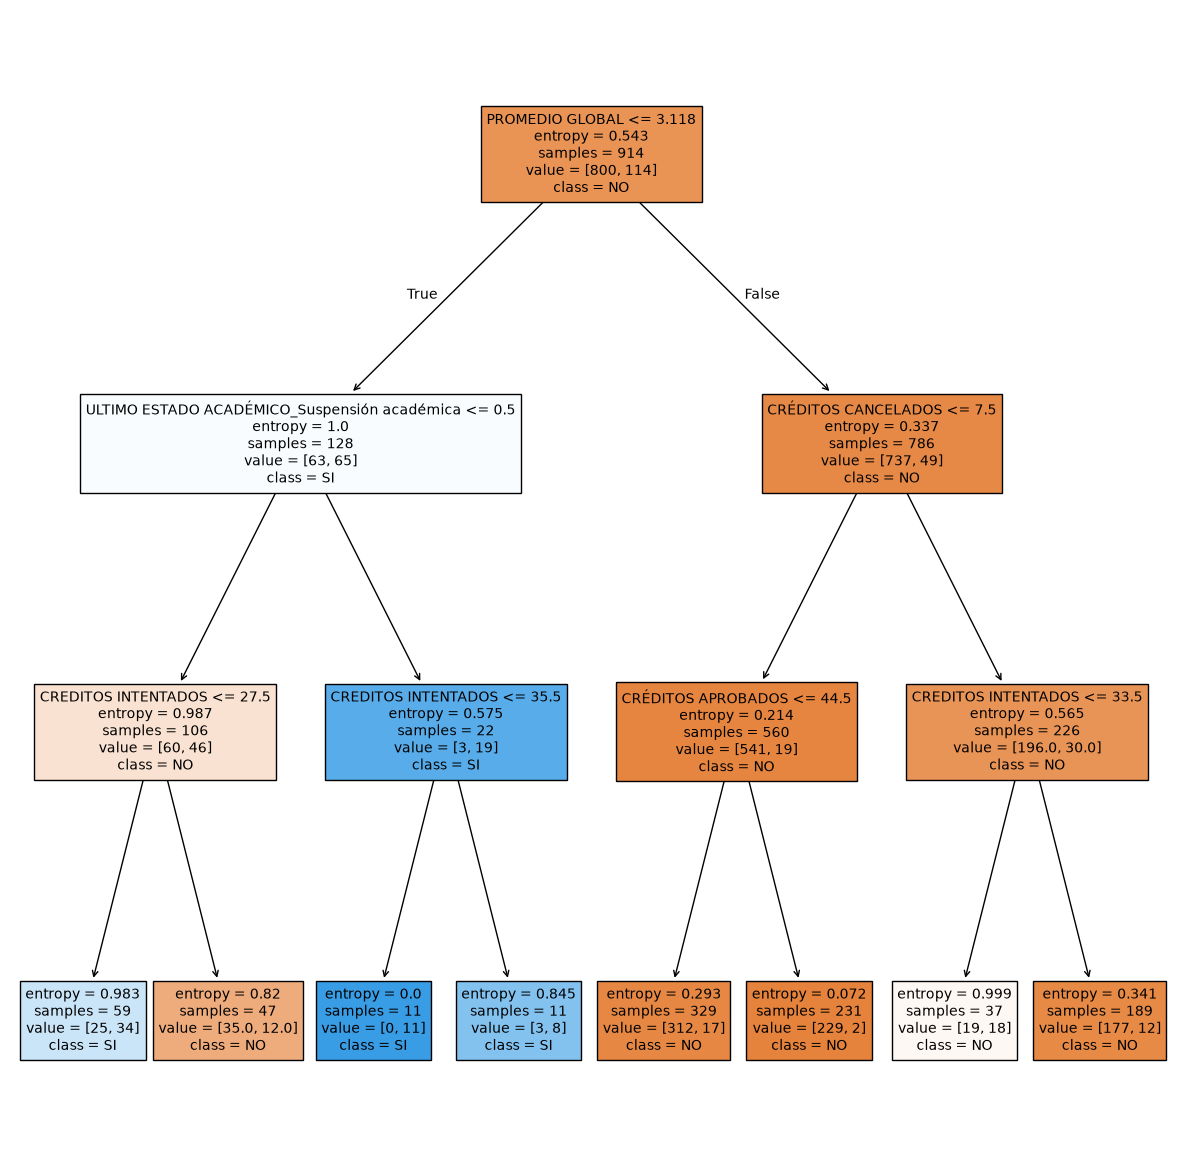

In [31]:
from sklearn import tree
model_Tree = tree.DecisionTreeClassifier(criterion='entropy', min_samples_leaf=1, max_depth=3)
data=data_org.copy()
data['DESERSIÓN'] = (
    data['DESERSIÓN']
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({'NO': 0, 'SI': 1})
).astype(int)

data = pd.get_dummies(data, columns=['ULTIMO ESTADO ACADÉMICO'], drop_first=True)
data['APOYOS ECONÓMICO EN MATRICULA']=data['APOYOS ECONÓMICO EN MATRICULA'].replace({'NO':0, 'SI':1})
data['SEXO']=data['SEXO'].replace({'M':0, 'F':1,'N':2})
data['APOYO INSTITUCIONAL']=data['APOYO INSTITUCIONAL'].replace({'NO':0, 'SI':1})
Y = data["DESERSIÓN"]
X = data.drop(["DESERSIÓN"],axis=1)
model_Tree.fit(X,Y)

from sklearn.tree import plot_tree

nombres_variables=X.columns.values

plt.figure(figsize=(15,15))
plot_tree(model_Tree, feature_names=nombres_variables, class_names=['NO','SI'], filled=True,fontsize=10)

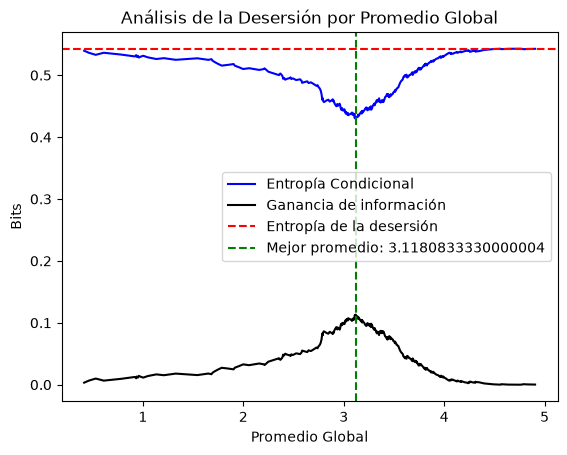

In [39]:
# Tomemos el promedio como referencia para mirar la entropía condicional de cada subgrupo 
promedios=sorted(list(data['PROMEDIO GLOBAL'].unique().astype(float)))
#Vamos a procesar cada subgrupo, separando entre cada uno de los promedios límites
division=[]
Hc=[]
Hcmin=10
for i in range(len(promedios)-1):
    promedio_inferior=promedios[i]
    promedio_superior=promedios[i+1]
    prom=(promedio_inferior+promedio_superior)/2
    sg1=data[data['PROMEDIO GLOBAL']<=prom]
    sg2=data[data['PROMEDIO GLOBAL']>=prom]
    pr1=sg1['DESERSIÓN'].value_counts().values
    pr2=sg2['DESERSIÓN'].value_counts().values
    entropia_condicional=H(pr1)*len(sg1)/len(data)+H(pr2)*len(sg2)/len(data)
    division.append(prom)
    Hc.append(entropia_condicional)
    if entropia_condicional<Hcmin:
        Hcmin=entropia_condicional
        mejor_promedio=prom
plt.plot(division,Hc, label='Entropía Condicional', color='blue')
plt.plot(division,Entropia_Desersion-np.array(Hc), label='Ganancia de información', color='black')

plt.axhline(y=Entropia_Desersion, color='r', linestyle='--', label='Entropía de la desersión')
plt.axvline(x=mejor_promedio, color='g', linestyle='--', label='Mejor promedio: '+str(mejor_promedio))
plt.legend()
plt.xlabel('Promedio Global')
plt.ylabel('Bits')
plt.title('Análisis de la Desersión por Promedio Global')
plt.show()

# Actividad: Entropía y ganancia de información

## Objetivo

En esta actividad se analizará un conjunto de datos de estudiantes con el propósito de determinar qué características contienen mayor información acerca de la **Escuela a la cual pertenece un estudiante**. Los datos están dentro del archivo **estudiantes_edad_escuela_genero_departamento.xlsx**.

La variable que se desea predecir es:

* **Escuela Programa Actual Pregrado**

Las variables disponibles para realizar el análisis son:

* **Departamento Nacimiento**
* **Edad**
* **Género**
* **Promedio notas**

El propósito principal no es construir todavía un modelo predictivo, sino utilizar los conceptos de **entropía, entropía condicional y ganancia de información** para determinar cuáles variables resultan más informativas para conocer la Escuela de un estudiante.

---

## 1. Exploración inicial de los datos

Cargue el conjunto de datos y realice una exploración inicial.

Identifique:

* Número total de registros.
* Número de Escuelas diferentes.
* Número de Departamentos de nacimiento diferentes.
* Distribución de estudiantes por Género.
* Valores mínimos, máximos y promedio de las variables Edad y Promedio de notas.
* Existencia de datos faltantes.

Analice si es necesario realizar algún procedimiento de limpieza o transformación antes de continuar.

---

## 2. Entropía inicial de la Escuela

Considere la variable aleatoria (Y):

$$
Y=\text{Escuela Programa Actual Pregrado}
$$

Determine experimentalmente la probabilidad de pertenecer a cada una de las Escuelas presentes en el conjunto de datos:

$$
P(Y=y_i)
$$

A partir de estas probabilidades calcule la entropía:

$$
H(Y)=-\sum_i P(Y=y_i)\log_2 P(Y=y_i)
$$

Reporte el resultado en **bits**.

Interprete el valor obtenido. En particular, explique qué representa esta entropía respecto a la incertidumbre que tenemos sobre la Escuela de un estudiante cuando no conocemos ninguna otra información acerca de él.

---

## 3. Información proporcionada por el Departamento de nacimiento

Considere ahora la variable:

$$
X=\text{Departamento Nacimiento}
$$

Para cada Departamento presente en los datos, determine la distribución de Escuelas correspondiente a los estudiantes nacidos en ese Departamento.

Calcule la entropía de la Escuela condicionada a cada posible Departamento:

$$
H(Y\mid X=x_j)
$$

y posteriormente calcule la entropía condicional:

$$
H(Y\mid X)
=\sum_j P(X=x_j)H(Y\mid X=x_j)
$$

Finalmente calcule la **ganancia de información**:

$$
IG(Y,X)=H(Y)-H(Y\mid X)
$$

Interprete el resultado: ¿cuánta incertidumbre acerca de la Escuela se elimina cuando conocemos el Departamento de nacimiento del estudiante?

---

## 4. Información proporcionada por el Género

Repita el procedimiento anterior utilizando:

$$
X=\text{Género}
$$

Calcule:

$$
H(Y\mid \text{Género})
$$

y posteriormente:

$$
IG(Y,\text{Género})
=H(Y)-H(Y\mid\text{Género})
$$

Analice si conocer el Género proporciona información relevante para determinar la Escuela a la cual pertenece el estudiante.

---

## 5. Variables numéricas: Edad y Promedio de notas

Las variables **Edad** y **Promedio de notas** presentan un problema diferente.

A diferencia del Género o del Departamento de nacimiento, pueden tomar muchos valores distintos. Utilizar directamente cada valor numérico como una categoría puede producir grupos con muy pocos estudiantes y conducir a conclusiones poco útiles.

Por esta razón, deberá diseñar un procedimiento que permita convertir estas variables numéricas en grupos.

Por ejemplo, una variable numérica (X) puede dividirse mediante uno o varios puntos de corte.

Con un único punto de corte (c):

$$
X\leq c
$$

y

$$
X>c
$$

se obtienen dos grupos.

Para cada punto de corte candidato puede calcularse:

$$
H(Y\mid X_c)
$$

y su correspondiente ganancia de información:

$$
IG(Y,X_c)=H(Y)-H(Y\mid X_c)
$$

Explore diferentes puntos de corte y determine aquel que produzca la **mayor ganancia de información**.

Realice este procedimiento independientemente para:

* Edad.
* Promedio de notas.

Explique cómo seleccionó los puntos de corte candidatos y cuál produjo el mejor resultado para cada variable.

---

## 6. Comparación de las cuatro variables

Construya una tabla final con los resultados obtenidos.

| Variable                | Entropía inicial | Entropía condicional | Ganancia de información |
| ----------------------- | ---------------: | -------------------: | ----------------------: |
| Departamento Nacimiento |                  |                      |                         |
| Edad                    |                  |                      |                         |
| Género                  |                  |                      |                         |
| Promedio notas          |                  |                      |                         |

Ordene las variables desde la que presenta **mayor ganancia de información** hasta la que presenta menor ganancia.

Responda:

**¿Cuál de las cuatro variables proporciona mayor información para determinar la Escuela de un estudiante?**

Justifique la respuesta a partir de los resultados obtenidos y no únicamente a partir de una apreciación visual de los datos.

---

## 7. Análisis de los resultados

Discuta los resultados obtenidos.

Como mínimo, responda las siguientes preguntas:

1. ¿Cuál es la entropía inicial de la variable Escuela y qué significa este valor?
2. ¿Cuál variable produjo la mayor reducción de entropía?
3. ¿Cuál produjo la menor?
4. ¿Conocer la variable con mayor ganancia permite determinar completamente la Escuela del estudiante?
5. ¿Por qué las variables Edad y Promedio de notas requieren un tratamiento diferente a Departamento y Género?
6. ¿Qué efecto podría tener seleccionar demasiados grupos o puntos de corte en una variable numérica?
7. ¿Una alta ganancia de información implica necesariamente una relación causal entre una característica y la Escuela? Explique.

---

# Entregables

La actividad deberá entregarse mediante **dos archivos**.

### 1. Libro interactivo

Entregue el notebook utilizado para desarrollar el análisis (`.ipynb`).

El libro deberá permitir reproducir completamente los resultados e incluir:

* Carga del conjunto de datos.
* Exploración y limpieza.
* Cálculo de probabilidades.
* Cálculo de la entropía inicial.
* Cálculo de las entropías condicionales.
* Cálculo de las ganancias de información.
* Procedimiento utilizado para Edad y Promedio de notas.
* Tabla comparativa final.
* Gráficas o visualizaciones que considere útiles.
* Comentarios en Markdown que permitan comprender el procedimiento realizado.

No es suficiente presentar únicamente los valores finales. Debe ser posible identificar mediante el código **cómo fueron calculados**.

### 2. Informe de resultados

Entregue un informe en formato PDF en el cual explique el procedimiento realizado y los principales resultados.

El informe deberá incluir:

* Descripción breve del problema.
* Características generales del conjunto de datos.
* Procedimiento utilizado para calcular la entropía inicial.
* Procedimiento utilizado para calcular la ganancia de información de cada variable.
* Explicación del tratamiento realizado sobre Edad y Promedio de notas.
* Tabla comparativa de resultados.
* Identificación de la variable con mayor ganancia de información.
* Interpretación y conclusiones.

El informe **no debe limitarse a copiar el código del notebook**. Su propósito es explicar qué se hizo, por qué se hizo y qué puede concluirse de los resultados.

---

## Resultado esperado

Al finalizar la actividad deberá ser posible establecer una relación entre los conceptos:

$$
\boxed{
\text{Probabilidad}
\rightarrow
\text{Entropía}
\rightarrow
\text{Entropía condicional}
\rightarrow
\text{Ganancia de información}
}
$$

y comprender que una característica es informativa respecto a una variable objetivo cuando conocerla permite **reducir la incertidumbre** acerca de dicha variable.

En este problema:

$$
\boxed{
IG(\text{Escuela},X)
=H(\text{Escuela})-H(\text{Escuela}\mid X)
}
$$

por lo que la característica con mayor ganancia de información será aquella que, dentro del conjunto de datos analizado, permita reducir en mayor medida la incertidumbre acerca de la Escuela a la cual pertenece un estudiante.
